## Simulating traffic around a lock
In this notebook, we simulate a lock on a network which two opposingly directed vessels have to pass. We add a pre-coded complex lock object on the graph. Vessels are locked together if they can fit inside the lock, and arrive within the clustering time window.

#### 0. Import libraries

In [1]:
# package(s) used for creating and geo-locating the graph
import networkx as nx
import pyproj
from shapely.geometry import Point, LineString
from shapely.ops import transform

# package(s) related to the simulation (creating the vessel, running the simulation)
import datetime
import simpy
import opentnsim
from opentnsim.core.logutils import logbook2eventtable
from opentnsim.core.plotutils import generate_vessel_gantt_chart
from scipy.stats import norm, uniform, expon

# import of modules important for locking
from opentnsim.lock import lock_new as lock_module
from opentnsim import vessel_traffic_service as vessel_traffic_service_module

# package(s) needed for inspecting the output
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("This notebook is executed with OpenTNSim version {}".format(opentnsim.__version__))

This notebook is executed with OpenTNSim version 1.3.7


#### 1. Define object classes

In [2]:
# make your preferred Vessel class out of available mix-ins.
Vessel = type(
    "Vessel", 
    (
        lock_module.PassesLockComplex,             # allows to interact with a lock
        opentnsim.core.Identifiable,               # allows to give the object a name and a random ID,
        opentnsim.core.Movable,                    # allows the object to move, with a fixed speed, while logging this activity
        opentnsim.core.VesselProperties,           # allows vessel to have dimensions, namely a length (L), width (B), and draught (T)
        opentnsim.core.ExtraMetadata,              # allow additional information, such as an arrival time (required for passing a lock)
        opentnsim.graph.HasMultiDiGraph,           # allow to operate on a graph that can include parallel edges from and to the same nodes
        opentnsim.output.HasOutput,                # allow additional output to be stored
    ), 
    {}
)

#### 2. Create graph

In [3]:
# define reference systems
wgs84eqd = pyproj.CRS('4087')
wgs84rad = pyproj.CRS('4326')

# define transformer functions
wgs84eqd_to_wgs84rad = pyproj.transformer.Transformer.from_crs(wgs84eqd,wgs84rad,always_xy=True).transform #equidistant wgs84 to radial wgs84
wgs84rad_to_wgs84eqd = pyproj.transformer.Transformer.from_crs(wgs84rad,wgs84eqd,always_xy=True).transform #radial wgs84 to equidistant wgs84

# create a directed graph
graph = nx.DiGraph()

# add nodes
graph.add_node('-1',geometry=transform(wgs84eqd_to_wgs84rad,Point(-350600,0)))
graph.add_node('0',geometry=transform(wgs84eqd_to_wgs84rad,Point(-5000,0)))
graph.add_node('1',geometry=transform(wgs84eqd_to_wgs84rad,Point(5000,0)))
graph.add_node('+1',geometry=transform(wgs84eqd_to_wgs84rad,Point(350600,0)))

# add edges
graph.add_edge('-1','0', weight=1)
graph.add_edge('0','-1', weight=1)
graph.add_edge('0','1', weight=1)
graph.add_edge('1','0', weight=1)
graph.add_edge('1','+1', weight=1)
graph.add_edge('+1','1', weight=1)


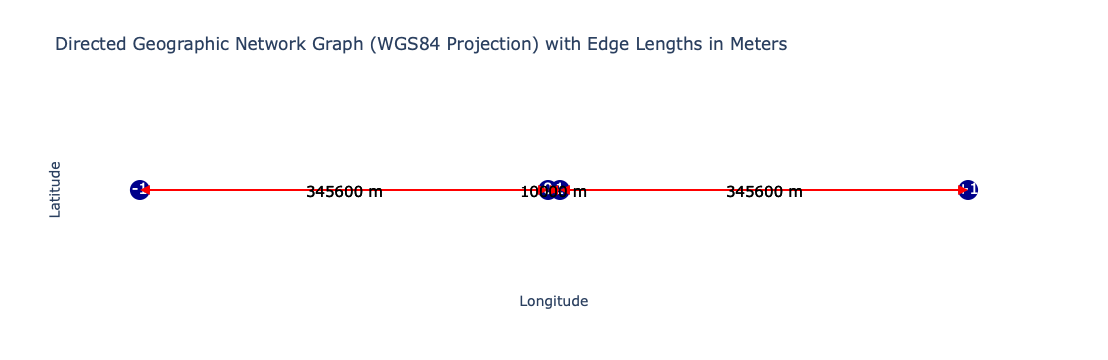

In [4]:
opentnsim.graph.plot_graph(graph)

#### 3. Run simulation

In [5]:
def generate_vessel(
    env,
    name,
    start_node,
    end_node,
    arrival_time,
    vessel_speed=4,
    vessel_length=100,
    vessel_beam=20,
    vessel_draft=10,
    vessel_type="tanker"):
    """
    Creates and returns a Vessel object with a computed route through the environment graph.

    Parameters:
    ----------
    env : Environment
        The simulation environment containing the graph and other context.
    name : str
        Human readabile identifier for the vessel.
    start_node : str or int
        The starting node in the graph (converted to string).
    end_node : str or int
        The destination node in the graph (converted to string).
    arrival_time : pd.Timestamp
        The scheduled arrival time of the vessel at the start node.
    vessel_speed : float, optional
        Speed of the vessel in knots or simulation units (default is 4).
    vessel_length : float, optional
        Length of the vessel in meters (default is 100).
    vessel_beam : float, optional
        Beam (width) of the vessel in meters (default is 20).
    vessel_draft : float, optional
        Draught (depth below waterline) of the vessel in meters (default is 10).
    vessel_type : str, optional
        Type of vessel (e.g., "tanker", "cargo", "container") (default is "tanker").

    Returns:
    -------
    Vessel or None
        A Vessel object initialized with the given parameters and route.
        Returns None if no valid path exists between start_node and end_node.
    """
    
    # Ensure nodes are strings
    start_node = str(start_node)
    end_node = str(end_node)

    try:
        route = nx.dijkstra_path(env.graph, start_node, end_node)
    except nx.NetworkXNoPath:
        print(f"⚠️ No path from {start_node} to {end_node}. Vessel {name} not created.")
        return None

    geometry = env.graph.nodes[start_node]['geometry']

    data_vessel = {
        "env": env,
        "name": name,
        "geometry": geometry,
        "route": route,
        "v": vessel_speed,
        "L": vessel_length,
        "B": vessel_beam,
        "T": vessel_draft,
        "type": vessel_type,
        "arrival_time": arrival_time,
    }

    vessel = Vessel(**data_vessel)

    return vessel

In [6]:
def generate_vessels_with_distributions(
    env,
    num_vessels,
    start_time,
    arrival_dist_up=None,
    arrival_dist_down=None,
    seed_up=None,
    seed_down=None):
    """
    Generates a list of vessels with interarrival times drawn from specified distributions
    for upward and downward directions. Supports independent seeding for reproducibility.

    Parameters
    ----------
    env : Environment
        The simulation environment containing the graph and vessel context.
    num_vessels : int
        Total number of vessels to generate. Vessels alternate between up and down directions.
    start_time : pd.Timestamp
        The initial timestamp from which vessel arrivals begin.
    arrival_dist_up : callable, optional
        A function returning interarrival times (in minutes) for upward-moving vessels.
        If None, defaults to an exponential distribution with mean 20 minutes.
    arrival_dist_down : callable, optional
        A function returning interarrival times (in minutes) for downward-moving vessels.
        If None, defaults to an exponential distribution with mean 20 minutes.
    seed_up : int or None, optional
        Seed for the random number generator used in upward direction.
    seed_down : int or None, optional
        Seed for the random number generator used in downward direction.

    Returns
    -------
    list of Vessel
        A list of Vessel objects with assigned routes and arrival times.
        Vessels for which no valid path exists are skipped.
    """

    vessels = []

    # Create independent random generators
    rng_up = np.random.default_rng(seed_up)
    rng_down = np.random.default_rng(seed_down)

    # Default to exponential distribution with mean 20 minutes
    if arrival_dist_up is None:
        arrival_dist_up = lambda: rng_up.exponential(scale=20)
    if arrival_dist_down is None:
        arrival_dist_down = lambda: rng_down.exponential(scale=20)

    up_time = start_time
    down_time = start_time

    for i in range(num_vessels):
        if i % 2 == 0:
            # Upward direction: -1 → +1
            start_node, end_node = "-1", "+1"
            delta_minutes = arrival_dist_up()
            arrival_time = up_time + pd.Timedelta(minutes=delta_minutes)
            up_time = arrival_time
        else:
            # Downward direction: +1 → -1
            start_node, end_node = "+1", "-1"
            delta_minutes = arrival_dist_down()
            arrival_time = down_time + pd.Timedelta(minutes=delta_minutes)
            down_time = arrival_time

        vessel = generate_vessel(
            env=env,
            name=f"Vessel {i + 1}",
            start_node=start_node,
            end_node=end_node,
            arrival_time=arrival_time
        )

        if vessel:
            vessels.append(vessel)

    return vessels

In [7]:
def mission(env, vessel):
    """
    Method that defines the mission of the vessel.
    
    In this case: 
        keep moving along the path until its end point is reached
    """
    while True:
        yield from vessel.move()
        
        if vessel.geometry == nx.get_node_attributes(env.graph, "geometry")[vessel.route[-1]]:
            break

In [8]:
# start simpy environment
simulation_start = datetime.datetime(2025, 1, 1, 0, 0, 0)
env = simpy.Environment(initial_time=simulation_start.timestamp())
env.epoch = simulation_start

# add graph to environment
env.graph = graph

# add components important for locking to the environment
env.vessel_traffic_service = vessel_traffic_service_module.VesselTrafficService(graph=graph)

lock = lock_module.IsLockComplex(
    env=env,
    name='Lock',
    node_open='0',
    node_A = '0',
    node_B = '1',
    distance_lock_doors_A_to_waiting_area_A = 4800,
    distance_lock_doors_B_to_waiting_area_B = 4800,
    distance_from_start_node_to_lock_doors_A = 4800,
    distance_from_end_node_to_lock_doors_B = 4800,
    lock_length = 400,
    lock_width = 50,
    lock_depth = 15,
    levelling_time = 300,
    sailing_distance_to_crossing_point = 1800,
    doors_opening_time= 300,
    doors_closing_time= 300,
    speed_reduction_factor_lock_chamber=0.5,
    sailing_in_time_gap_through_doors = 300,
    sailing_in_speed_sea = 1.5,
    sailing_in_speed_canal = 1.5,
    sailing_out_time_gap_through_doors = 120,
    sailing_time_before_opening_lock_doors = 600,
    sailing_time_before_closing_lock_doors = 120,
    registration_nodes = ['-1','+1'],
)

start_time = pd.Timestamp('2025-01-01 00:00:00')

# Example using numpy
# Create independent random generators
rng_up = np.random.default_rng(123)
rng_down = np.random.default_rng(456)

# Exponential distributions with different means (scale = mean)
arrival_dist_up = lambda: rng_up.exponential(scale=5)   # mean 30 minutes
arrival_dist_down = lambda: rng_down.exponential(scale=5)  # mean 15 minutes

# Example using scipy.stats and other distributions
# # Create independent random generators
# rng_up = np.random.default_rng(123)
# rng_down = np.random.default_rng(456)

# # Exponential distributions using SciPy
# arrival_dist_up = lambda: expon(scale=30).rvs(random_state=rng_up)
# arrival_dist_down = lambda: expon(scale=15).rvs(random_state=rng_down)

vessels = generate_vessels_with_distributions(
    env=env,
    num_vessels=40,
    start_time=start_time,
    arrival_dist_up=arrival_dist_up,
    arrival_dist_down=arrival_dist_down,
    seed_up=123,
    seed_down=456
)

for vessel in vessels:
    env.process(mission(env, vessel))

env.run()

Vessel 2 2025-01-01 00:02:27.392402 new
Vessel 1 2025-01-01 00:02:59.091748 new
Vessel 3 2025-01-01 00:03:34.201066 planned
Vessel 4 2025-01-01 00:04:33.526756 planned
Vessel 4 Vessel 1 0 days 00:06:02.980561764
Vessel 4 Vessel 3 0 days 00:06:02.980561764
Vessel 5 2025-01-01 00:04:49.739476 planned
Vessel 6 2025-01-01 00:05:44.510912 planned
Vessel 6 Vessel 1 0 days 00:07:00
Vessel 6 Vessel 3 0 days 00:07:00
Vessel 6 Vessel 5 0 days 00:07:00
Vessel 7 2025-01-01 00:06:22.129110 planned
Vessel 9 2025-01-01 00:06:49.669908 new
Vessel 8 2025-01-01 00:08:12.568315 planned
Vessel 8 Vessel 1 0 days 00:07:00
Vessel 8 Vessel 3 0 days 00:07:00
Vessel 8 Vessel 5 0 days 00:07:00
Vessel 8 Vessel 7 0 days 00:07:00
Vessel 8 Vessel 9 0 days 00:10:00
Vessel 11 2025-01-01 00:18:35.156165 planned
Vessel 10 2025-01-01 00:21:11.223921 new
Vessel 12 2025-01-01 00:21:26.050142 planned
Vessel 14 2025-01-01 00:22:35.995695 planned
Vessel 16 2025-01-01 00:38:25.194442 planned
Vessel 13 2025-01-01 00:40:01.69667

#### 4. Inspect output

In [9]:
# load the logbook data into a dataframe
lock_df = pd.DataFrame.from_dict(lock.logbook)

print("'{}' logbook data:".format(lock.name))  
print('')

display(lock_df)

'Lock' logbook data:



,Message,Timestamp,Value,Geometry
0,Lock doors closing start,2025-01-01 00:02:27.392402,{},0
1,Lock doors closing stop,2025-01-01 00:07:27.392402,{},0
2,Lock chamber converting start,2025-01-01 00:07:27.392402,{},0
3,Lock chamber converting stop,2025-01-01 00:12:27.392402,{},0
4,Lock doors opening start,2025-01-01 00:12:27.392402,{},0
...,...,...,...,...
79,Lock doors closing stop,2025-01-02 09:54:42.000000,{},1
80,Lock chamber converting start,2025-01-02 09:54:42.000000,{},1
81,Lock chamber converting stop,2025-01-02 09:59:42.000000,{},0
82,Lock doors opening start,2025-01-02 09:59:42.000000,{},0


#### Gantt chart of event table

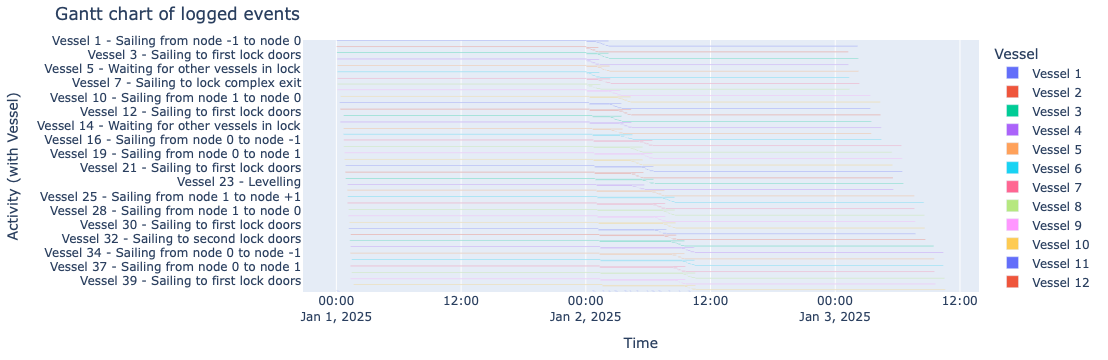

In [10]:
df_eventtable = opentnsim.core.logutils.logbook2eventtable([*vessels, lock])
fig = generate_vessel_gantt_chart(df_eventtable)

#### Time-distance diagram of vessels passing the lock and planning info

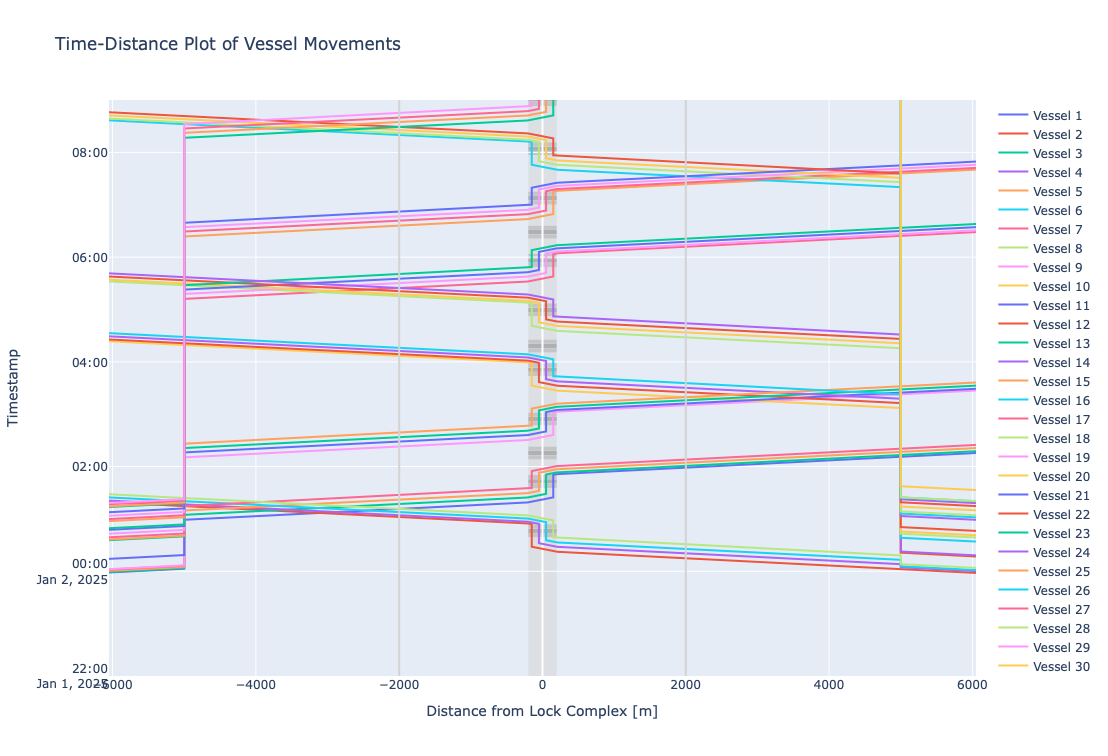

In [11]:
def cm_to_pixels(cm):
    return cm * 37.8 # Set figure height to 10 cmfig.update_layout(height=cm_to_pixels(10))

# We can plot the time-distance diagram
fig = lock.create_time_distance_plot(vessels = vessels, 
                                     xlimmin = -6050, 
                                     xlimmax = 6050,
                                     ylimmin = pd.Timestamp('2025-01-01 22:00:00'),
                                     ylimmax = pd.Timestamp('2025-01-02 09:00:00'),
                                     method='Plotly')

fig.update_layout(height=cm_to_pixels(20))

In [12]:
lock.vessel_planning

,id,bound,L,B,T,operation_index,time_of_registration,time_of_acceptance,time_arrival_at_waiting_area,time_arrival_at_lineup_area,time_lock_passing_start,time_lock_entry_start,time_lock_entry_stop,time_lock_departure_start,time_lock_departure_stop,time_lock_passing_stop,delay,time_potential_lock_door_opening_stop,time_potential_lock_door_closure_start
0,d2c64abd-90e2-4345-bfd2-ece39a2099ad,1,100,20,10,1,2025-01-01 00:02:27.392402,2025-01-01 00:02:27.392402,2025-01-02 00:02:27.392402,NaN,2025-01-02 00:14:57.392402,2025-01-02 00:22:27.392402,2025-01-02 00:28:07.565188470,2025-01-02 00:53:56.161300822,2025-01-02 00:54:44.757413174,2025-01-02 01:02:14.757413174,0 days 00:10:48.596112352,2025-01-02 00:12:27.392402000,2025-01-02 00:28:07.565188470
1,1c0db15a-3bc7-4f38-8da2-8cf7727ee36c,0,100,20,10,2,2025-01-01 00:02:59.091748,2025-01-01 00:02:59.091748,2025-01-02 00:02:59.091748,NaT,2025-01-02 01:11:29.141862586,2025-01-02 01:18:59.141862586,2025-01-02 01:24:39.314649056,2025-01-02 01:50:27.910761408,2025-01-02 01:51:16.506873760,2025-01-02 01:58:46.506873760,0 days 01:06:48.646226938,2025-01-02 01:08:59.141862586,2025-01-02 01:24:39.314649056
2,3445f965-22ae-432a-abf6-6924f39bdb3f,0,100,20,10,2,2025-01-01 00:03:34.201066,2025-01-01 00:03:34.201066,2025-01-02 00:03:34.201066,NaT,2025-01-02 01:17:09.314649056,2025-01-02 01:24:39.314649056,2025-01-02 01:28:42.295210820,2025-01-02 01:50:50.718536702,2025-01-02 01:53:16.506873760,2025-01-02 02:00:46.506873760,0 days 00:26:48.596112352,2025-01-02 01:14:39.314649056,2025-01-02 01:28:42.295210820
3,9d259d43-d54c-4041-839f-adb20c98d78a,1,100,20,10,1,2025-01-01 00:04:33.526756,2025-01-01 00:04:33.526756,2025-01-02 00:04:33.526756,NaN,2025-01-02 00:20:37.565188470,2025-01-02 00:28:07.565188470,2025-01-02 00:32:10.545750234,2025-01-02 00:54:18.969076116,2025-01-02 00:56:44.757413174,2025-01-02 01:04:14.757413174,0 days 00:06:45.615550588,2025-01-02 00:18:07.565188470,2025-01-02 00:32:10.545750234
4,c9d4d8a6-4489-432a-bb4e-7af08af5bd51,0,100,20,10,2,2025-01-01 00:04:49.739476,2025-01-01 00:04:49.739476,2025-01-02 00:04:49.739476,NaT,2025-01-02 01:22:09.314649056,2025-01-02 01:29:39.314649056,2025-01-02 01:32:05.102986114,2025-01-02 01:52:50.718536702,2025-01-02 01:56:53.699098466,2025-01-02 02:04:23.699098466,0 days 00:17:22.807775294,2025-01-02 01:19:39.314649056,2025-01-02 01:32:05.102986114
5,79a41f00-d8e3-45c5-a8e0-85a38c7d95b9,1,100,20,10,1,2025-01-01 00:05:44.510912,2025-01-01 00:05:44.510912,2025-01-02 00:05:44.510912,NaN,2025-01-02 00:25:37.565188470,2025-01-02 00:33:07.565188470,2025-01-02 00:35:33.353525528,2025-01-02 00:56:18.969076116,2025-01-02 01:00:21.949637880,2025-01-02 01:07:51.949637880,0 days 00:03:22.807775294,2025-01-02 00:23:07.565188470,2025-01-02 00:35:33.353525528
6,ccf73277-a7ca-455e-859b-57ab9b0e9560,0,100,20,10,2,2025-01-01 00:06:22.129110,2025-01-01 00:06:22.129110,2025-01-02 00:06:22.129110,NaT,2025-01-02 01:27:09.314649056,2025-01-02 01:34:39.314649056,2025-01-02 01:35:27.910761408,2025-01-02 01:54:50.718536702,2025-01-02 02:00:30.891323172,2025-01-02 02:08:00.891323172,0 days 00:07:00,2025-01-02 01:24:39.314649056,2025-01-02 01:35:27.910761408
7,ded3384e-7d6d-40f4-9892-f083eccb0efd,0,100,20,10,4,2025-01-01 00:06:49.669908,2025-01-01 00:06:49.669908,2025-01-02 00:06:49.669908,NaT,2025-01-02 02:23:00.891323172,2025-01-02 02:30:30.891323172,2025-01-02 02:36:11.064109642,2025-01-02 03:01:59.660221994,2025-01-02 03:02:48.256334346,2025-01-02 03:10:18.256334346,0 days 02:14:29.817527524,2025-01-02 02:20:30.891323172,2025-01-02 02:36:11.064109642
8,ce661960-83b4-4562-a43c-61e853a0679f,1,100,20,10,1,2025-01-01 00:08:12.568315,2025-01-01 00:08:12.568315,2025-01-02 00:08:12.568315,NaN,2025-01-02 00:30:37.565188470,2025-01-02 00:38:07.565188470,2025-01-02 00:38:56.161300822,2025-01-02 00:58:18.969076116,2025-01-02 01:03:59.141862586,2025-01-02 01:11:29.141862586,0 days 00:00:00,2025-01-02 00:28:07.565188470,2025-01-02 00:38:56.161300822
9,8ccca090-5dd9-43e4-8639-9f8d2480a7f

In [13]:
lock.operation_planning

,bound,vessels,capacity_L,capacity_B,time_potential_lock_door_opening_stop,time_operation_start,time_entry_start,time_entry_stop,time_door_closing_start,time_door_closing_stop,...,time_door_opening_stop,time_departure_start,time_departure_stop,time_operation_stop,time_potential_lock_door_closure_start,wlev_A,wlev_B,maximum_individual_delay,total_delay,status
lock_operation,,,,,,,,,,,,,,,,,,,,,
0,0,[],400,50,2025-01-01 00:02:27.392402,2025-01-01 00:02:27.392402,2025-01-01 00:02:27.392402,2025-01-01 00:02:27.392402,2025-01-01 00:02:27.392402,2025-01-01 00:07:27.392402,...,2025-01-01 00:17:27.392402,2025-01-01 00:17:27.392402,2025-01-01 00:17:27.392402,2025-01-01 00:17:27.392402,2025-01-01 00:17:27.392402,NaN,NaN,0 days 00:00:00,0 days 00:00:00,available
1,1,"[<__main__.Vessel object at 0x177cfabd0>, <__m...",0,-30,2025-01-02 00:12:27.392402,2025-01-02 00:14:57.392402,2025-01-02 00:22:27.392402,2025-01-02 00:38:56.161300822,2025-01-02 00:38:56.161300822,2025-01-02 00:43:56.161300822,...,2025-01-02 00:53:56.161300822,2025-01-02 00:53:56.161300822,2025-01-02 01:03:59.141862586,2025-01-02 01:11:29.141862586,2025-01-02 01:05:59.141862586,NaN,NaN,0 days 00:10:48.596112352,0 days 00:20:57.019438234,unavailable
2,0,"[<__main__.Vessel object at 0x177cefb90>, <__m...",0,-30,2025-01-02 01:08:59.141862586,2025-01-02 01:11:29.141862586,2025-01-02 01:18:59.141862586,2025-01-02 01:35:27.910761408,2025-01-02 01:35:27.910761408,2025-01-02 01:40:27.910761408,...,2025-01-02 01:50:27.910761408,2025-01-02 01:50:27.910761408,2025-01-02 02:00:30.891323172,2025-01-02 02:08:00.891323172,2025-01-02 02:02:30.891323172,NaN,NaN,0 days 01:06:48.646226938,0 days 01:58:00.050114584,unavailable
3,1,[],400,50,2025-01-02 02:08:00.891323172,2025-01-02 02:08:00.891323172,2025-01-02 02:08:00.891323172,2025-01-02 02:08:00.891323172,2025-01-02 02:08:00.891323172,2025-01-02 02:13:00.891323172,...,2025-01-02 02:23:00.891323172,2025-01-02 02:23:00.891323172,2025-01-02 02:23:00.891323172,2025-01-02 02:23:00.891323172,2025-01-02 02:23:00.891323172,NaN,NaN,0 days 00:12:30,0 days 00:00:00,available
4,0,"[<__main__.Vessel object at 0x177d45590>, <__m...",0,-30,2025-01-02 02:20:30.891323172,2025-01-02 02:23:00.891323172,2025-01-02 02:30:30.891323172,2025-01-02 02:46:59.660221994,2025-01-02 02:46:59.660221994,2025-01-02 02:51:59.660221994,...,2025-01-02 03:01:59.660221994,2025-01-02 03:01:59.660221994,2025-01-02 03:12:02.640783758,2025-01-02 03:19:32.640783758,2025-01-02 03:14:02.640783758,NaN,NaN,0 days 02:14:29.817527524,0 days 02:24:38.240853406,unavailable
5,1,"[<__main__.Vessel object at 0x177d36450>, <__m...",0,-30,2025-01-02 03:17:02.640783758,2025-01-02 03:19:32.640783758,2025-01-02 03:27:02.640783758,2025-01-02 03:43:31.409682580,2025-01-02 03:43:31.409682580,2025-01-02 03:48:31.409682580,...,2025-01-02 03:58:31.409682580,2025-01-02 03:58:31.409682580,2025-01-02 04:08:34.390244344,2025-01-02 04:16:04.390244344,2025-01-02 04:10:34.390244344,NaN,NaN,0 days 02:56:40.012975110,0 days 03:48:48.436300992,unavailable
6,0,[],400,50,2025-01-02 04:10:34.390244344,2025-01-02 04:10:34.390244344,2025-01-02 04:10:34.390244344,2025-01-02 04:10:34.390244344,2025-01-02 04:10:34.390244344,2025-01-02 04:15:34.390244344,...,2025-01-02 04:25:34.390244344,2025-01-02 04:25:34.390244344,2025-01-02 04:25:34.390244344,2025-01-02 04:25:34.390244344,2025-01-02 04:25:34.390244344,NaN,NaN,0 days 00:00:00,0 days 00:00:00,available
7,1,"[<__main__.Vessel object at 0x177d57150>, <__m...",0,-30,2025-01-02 04:25:34.390244344,2025-01-02 04:28:04.390244344,2025-01-02 04:35:34.390244344,2025-01-02 04:52:03.159143166,2025-01-02 04:52:03.159143166,2025-01-02 04:57:03.159143166,...,2025-01-02 05:07:03.159143166,2025-01-02 05:07:03.159143166,2025-01-02 05:17:06.139704930,2025-01-02 05:24:36.139704930,2025-01-02 05:19:06.139704930,NaN,NaN,0 days 03:43:18.187777696,0 days 03:53:26.611103578,unavailable
8,0,"[<__main__.Vessel object at 0x177d55f10>, <__m...",0,-30,2025-01-02 05:22:06.139704930,2025-01-02 05:24:36

In [14]:
lock.operation_planning.apply(lambda x: [vessel.name for vessel in (x.vessels)], axis=1)

lock_operation
0                                               []
1         [Vessel 2, Vessel 4, Vessel 6, Vessel 8]
2         [Vessel 1, Vessel 3, Vessel 5, Vessel 7]
3                                               []
4      [Vessel 9, Vessel 11, Vessel 13, Vessel 15]
5     [Vessel 10, Vessel 12, Vessel 14, Vessel 16]
6                                               []
7     [Vessel 18, Vessel 20, Vessel 22, Vessel 24]
8     [Vessel 17, Vessel 19, Vessel 21, Vessel 23]
9                                               []
10    [Vessel 25, Vessel 27, Vessel 29, Vessel 31]
11    [Vessel 26, Vessel 28, Vessel 30, Vessel 32]
12    [Vessel 33, Vessel 35, Vessel 37, Vessel 39]
13    [Vessel 34, Vessel 36, Vessel 38, Vessel 40]
dtype: object

#### Vessel delays: individual delays and overall average

In [15]:
delays = []
for vessel in vessels:
    vessel_df = pd.DataFrame(vessel.logbook)
    waiting_stop = vessel_df[vessel_df.Message == "Waiting stop"]
    if not waiting_stop.empty:
        delay = (waiting_stop.Timestamp-vessel.metadata["arrival_time"]).iloc[0]
    else:
        delay = pd.Timedelta(seconds=0)
    delays.append(delay)

In [16]:
print(f"The average vessel delay is {np.round(np.average(delays).total_seconds()/60,1)} minutes")

The average vessel delay is 0.0 minutes


#### Simulated intensity (vessels per hour)
'get_vessels_during_leveling':
- Identify locking cycles (by looking at the lock logbook)
- From the vessel list identify which vessels were in the lock during that locking cycle

'calculate_cycle_looptimes':
- Using the info derived from 'get_vessels_during_leveling' calculate looptimes

'calculate_detailed_cycle_time':
- using the info from 'get_vessels_during_leveling' and 'calculate_cycle_looptimes' calculate detailed cycle times

In [17]:
leveling_cycles = opentnsim.lock.logutils.get_vessels_during_leveling(lock, vessels)
looptimes_df = opentnsim.lock.logutils.calculate_cycle_looptimes(leveling_cycles, vessels)
Tc_df = opentnsim.lock.logutils.calculate_detailed_cycle_time(lock, vessels, leveling_cycles)

display(pd.DataFrame(leveling_cycles))
display(looptimes_df)
display(Tc_df)

,leveling_start,leveling_stop,vessels_present
0,2025-01-01 00:07:27.392402,2025-01-01 00:12:27.392402,[]
1,2025-01-02 00:43:56.161300,2025-01-02 00:48:56.161300,"[Vessel 2, Vessel 4, Vessel 6, Vessel 8]"
2,2025-01-02 01:40:28.000000,2025-01-02 01:45:28.000000,"[Vessel 1, Vessel 3, Vessel 5, Vessel 7]"
3,2025-01-02 02:13:00.891324,2025-01-02 02:18:00.891324,[]
4,2025-01-02 02:52:00.000000,2025-01-02 02:57:00.000000,"[Vessel 9, Vessel 11, Vessel 13, Vessel 15]"
5,2025-01-02 03:48:31.409682,2025-01-02 03:53:31.409682,"[Vessel 10, Vessel 12, Vessel 14, Vessel 16]"
6,2025-01-02 04:15:34.390244,2025-01-02 04:20:34.390244,[]
7,2025-01-02 04:57:03.159142,2025-01-02 05:02:03.159142,"[Vessel 18, Vessel 20, Vessel 22, Vessel 24]"
8,2025-01-02 05:53:35.000000,2025-01-02 05:58:35.000000,"[Vessel 17, Vessel 19, Vessel 21, Vessel 23]"
9,2025-01-02 06:26:07.889165,2025-01-02 06:31:07.889165,[]


,cycle,looptime_seconds
0,1,0.000000
1,2,NaN
2,3,899.999999
3,4,NaN
4,5,NaN
5,6,899.660222
6,7,NaN
7,8,NaN
8,9,899.999999
9,10,NaN


,t_l_up,sum_t_i_up,T_close_up,T_waterlevel_up,T_open_up,sum_t_u_up,t_l_down,sum_t_i_down,T_close_down,T_waterlevel_down,T_open_down,sum_t_u_down,Tc_seconds,up_vessels,down_vessels,I_s
0,0.000000,0.000000,300.0,300.0,300.0,0.000000,0.000000,988.768898,300.0,300.0,300.0,602.980563,3391.749461,[],"[Vessel 2, Vessel 4, Vessel 6, Vessel 8]",4.245597
1,899.999999,988.768899,300.0,300.0,300.0,602.980561,0.000000,0.000000,300.0,300.0,300.0,0.000000,4291.749459,"[Vessel 1, Vessel 3, Vessel 5, Vessel 7]",[],3.355275
2,0.000000,988.768898,300.0,300.0,300.0,602.980561,899.660222,988.768899,300.0,300.0,300.0,602.980562,5883.159142,"[Vessel 9, Vessel 11, Vessel 13, Vessel 15]","[Vessel 10, Vessel 12, Vessel 14, Vessel 16]",4.895329
3,0.000000,0.000000,300.0,300.0,300.0,0.000000,0.000000,988.768898,300.0,300.0,300.0,602.980562,3391.749460,[],"[Vessel 18, Vessel 20, Vessel 22, Vessel 24]",4.245597
4,899.999999,988.768899,300.0,300.0,300.0,602.980561,0.000000,0.000000,300.0,300.0,300.0,0.000000,4291.749459,"[Vessel 17, Vessel 19, Vessel 21, Vessel 23]",[],3.355275
5,0.000000,988.768898,300.0,300.0,300.0,602.980561,899.658065,988.768898,300.0,300.0,300.0,602.980563,5883.156985,"[Vessel 25, Vessel 27, Vessel 29, Vessel 31]","[Vessel 26, Vessel 28, Vessel 30, Vessel 32]",4.895331
6,899.999999,988.768899,300.0,300.0,300.0,602.980562,900.000000,988.768898,300.0,300.0,300.0,602.980561,6783.498919,"[Vessel 33, Vessel 35, Vessel 37, Vessel 39]","[Vessel 34, Vessel 36, Vessel 38, Vessel 40]",4.245597


In [18]:
for index, row in Tc_df.iterrows():
    print('Locking cycle {} has an intensity of {:.2f} vessels per hour'.format(index+1, row['I_s']))

Locking cycle 1 has an intensity of 4.25 vessels per hour
Locking cycle 2 has an intensity of 3.36 vessels per hour
Locking cycle 3 has an intensity of 4.90 vessels per hour
Locking cycle 4 has an intensity of 4.25 vessels per hour
Locking cycle 5 has an intensity of 3.36 vessels per hour
Locking cycle 6 has an intensity of 4.90 vessels per hour
Locking cycle 7 has an intensity of 4.25 vessels per hour


#### Estimated capacity (vessels per hour)

In [19]:
n_max = 4
vessel_speed_outside_of_lock = 4

# Part III, Ch3, Eq. 3.2 (NB: de helft van de looptime wordt hier effectief geimplementeerd door de sailing to lock te berekenen)
t_sailing_to_lock = lock.sailing_distance_to_crossing_point/vessel_speed_outside_of_lock
T_entering = t_sailing_to_lock + (n_max-1)*lock.sailing_in_time_gap_through_doors + 50/2

# Part III, Ch3, Eq. 3.3
T_operation = lock.doors_closing_time + lock.levelling_time + lock.doors_opening_time

# Part III, Ch3, Eq. 3.4 (NB: de helft van de looptime wordt hier effectief geimplementeerd door de sailing out of lock te berekenen)
t_sailing_out_of_lock = lock.sailing_distance_to_crossing_point/vessel_speed_outside_of_lock
T_exiting = t_sailing_out_of_lock + (n_max-1)*lock.sailing_out_time_gap_through_doors + 350/2

# Part III, Ch3, Eq. 3.1
T_locking = T_entering + T_operation + T_exiting
T_c = 2 * T_locking

C_s = 2*n_max / (T_c/3600)

print(f"The capacity of the lock is {np.round(C_s,1)} vessels per hour")

The capacity of the lock is 4.4 vessels per hour
